# Project: Investigate TMDb Movie Dataset
**Prepared by:** Abdulmalk Alnajem

## Introduction
In this project, we will analyze a dataset containing information about thousands of movies from the Movie Database (TMDb). This dataset includes attributes such as popularity, budget, revenue, release year, and user ratings. 

Our goal is to clean the data, explore patterns, and discover what factors make a movie successful in the industry.

### Research Questions
1. **Budget vs. Revenue:** Does a higher adjusted budget (`budget_adj`) correlate with higher adjusted revenue (`revenue_adj`)?
2. **Ratings vs. Success:** How does the user rating (`vote_average`) relate to a movie's financial success or popularity?
3. **Genre Trends:** Which movie genres (`genres`) have been the most popular and profitable over the decades?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load the dataset
df = pd.read_csv('tmdb-movies.csv')

# Display the first 5 rows to verify data loading
df.head(5)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [3]:
# Assess data types, non-null counts, and shape of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [5]:
# Count the number of missing values (nulls) in each column
df.isnull().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

## Data Cleaning Plan
Based on our data assessment, we will execute the following cleaning steps:

1. **Drop Unnecessary Columns:** Remove `homepage`, `tagline`, `keywords`, and `production_companies` since they have a high volume of missing values and are not needed for our research questions.
2. **Handle Missing Rows:** Drop rows with missing values in the `genres` column (23 rows) to ensure accurate genre analysis.
3. **Filter Out Zero Values:** Remove rows where `budget_adj` or `revenue_adj` are equal to 0, as these represent missing financial data that would skew our correlation and profitability analysis.
4. **Remove Duplicates:** Check for and remove any duplicate rows to ensure data integrity.

In [6]:
# Drop columns that are not needed for our analysis
columns_to_drop = ['homepage', 'tagline', 'keywords', 'production_companies']
df.drop(columns=columns_to_drop, axis=1, inplace=True)

# Verify that the columns were dropped by checking the new columns list
df.columns

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'director', 'overview', 'runtime', 'genres', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='object')

In [8]:
# Remove duplicate rows from the dataset
df.drop_duplicates(inplace=True)

# Verify if there are any remaining duplicates (should output 0)
df.duplicated().sum()

np.int64(0)

In [9]:
# Filter the dataframe to keep only rows where both budget_adj and revenue_adj are greater than 0
df = df[(df['budget_adj'] > 0) & (df['revenue_adj'] > 0)]

# Check the new dimensions of the dataset after dropping zeros and duplicates
df.shape

(3854, 17)

In [11]:
# Drop any remaining rows where the genres column is missing (null)
df.dropna(subset=['genres'], inplace=True)

# Final check to ensure there are absolutely no missing values left in the dataset
df.isnull().sum()

id                0
imdb_id           0
popularity        0
budget            0
revenue           0
original_title    0
cast              4
director          1
overview          0
runtime           0
genres            0
release_date      0
vote_count        0
vote_average      0
release_year      0
budget_adj        0
revenue_adj       0
dtype: int64

## Exploratory Data Analysis (EDA)

### Question 1: Does a higher adjusted budget (`budget_adj`) always guarantee higher adjusted revenue (`revenue_adj`)?
In this section, we will explore the relationship between the budget spent on producing a movie and the revenue it generated. We will create a scatter plot to visualize if there is a positive correlation between these two financial metrics.

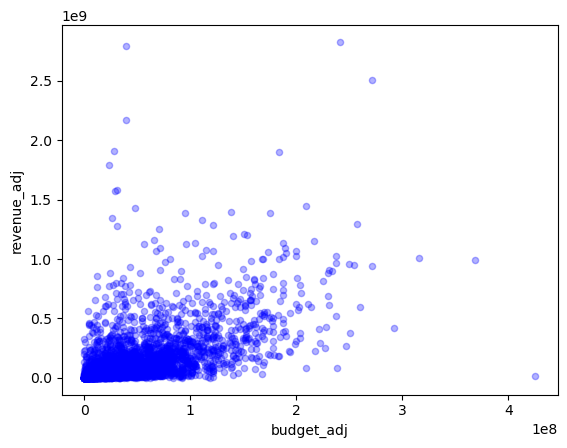

In [17]:
# 1. Calculate profit
df['profit'] = df['revenue_adj'] - df['budget_adj']

# 2. Draw the scatter plot
df.plot(kind='scatter', x='budget_adj', y='revenue_adj', alpha=0.3, color='blue');

#### Finding for Question 1:
The scatter plot shows a positive trend between the adjusted budget and adjusted revenue. As the budget increases, the revenue generally tends to increase as well. However, most movies are clustered in the low-budget, low-revenue region. We also notice some exceptions: some movies with moderate budgets achieved massive box office success, while a few high-budget films failed to generate high revenues.

### Question 2: How does the user rating (`vote_average`) relate to a movie's financial success?
In this section, we will analyze whether higher-rated movies tend to make more profit. We will use a scatter plot to visualize the correlation between the vote average and movie profit.

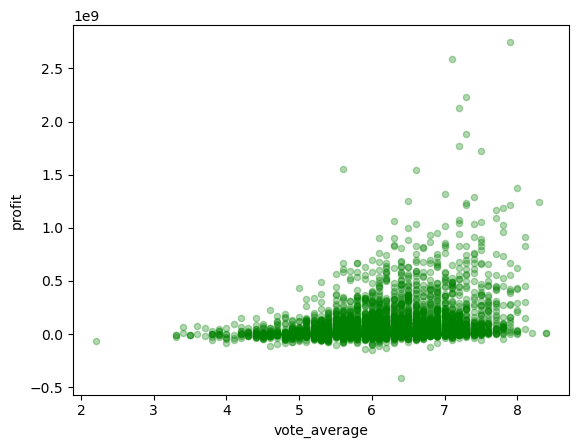

In [19]:
# Draw a scatter plot for vote average vs profit
df.plot(kind='scatter', x='vote_average', y='profit', alpha=0.3, color='green');

#### Finding for Question 2:
From the scatter plot, we can see that most profitable movies (high on the Y-axis) tend to have user ratings between 6 and 8. It is rare for movies with very low ratings (below 5) to achieve huge financial success. This suggests that while a movie doesn't need a perfect 10 to be highly profitable, it generally needs to be well-received and acceptable by the audience (above 6) to make significant profits.

### Question 3: Which movie genres (`genres`) are the most popular and profitable?
In this final question, we will explore which types of movies (such as Action, Comedy, or Drama) tend to perform best in terms of popularity and average profit.

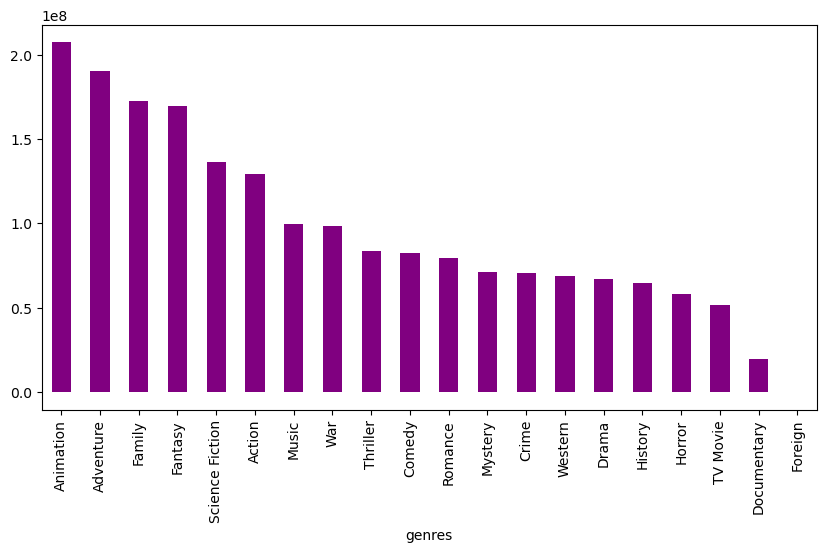

In [20]:
# 1. Split the genres string into a list and explode them into separate rows
df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].str.split('|')
df_genres = df_genres.explode('genres')

# 2. Group by genres and calculate the mean of profit
genre_profit = df_genres.groupby('genres')['profit'].mean().sort_values(ascending=False)

# 3. Plot the results in a simple bar chart
genre_profit.plot(kind='bar', color='purple', figsize=(10, 5));

#### Finding for Question 3:
Based on the bar chart, we can conclude that **Animation** and **Adventure** movies are the most profitable genres on average, followed closely by Family and Fantasy films. On the other hand, **Documentaries** and **Foreign** films tend to generate the lowest average profits in the dataset.

## Conclusions

### Summary of Findings
1. **Budget vs. Revenue:** We found a clear positive correlation between a movie's adjusted budget and its adjusted revenue. While investing more budget generally yields higher returns, it is not a 100% guarantee, as some high-budget films still failed commercially.
2. **Ratings vs. Profit:** Most financially successful movies tend to score between 6 and 8 in user ratings (`vote_average`). Movies with low ratings (below 5) rarely make high profits.
3. **Genre Popularity:** **Animation** and **Adventure** are the top-earning movie genres on average, whereas **Documentaries** and **Foreign** movies sit at the bottom of the profit ladder.

### Limitations
* **Missing Data:** We had to drop thousands of rows during the cleaning phase due to missing or zero values in crucial financial metrics (`budget` and `revenue`), which might introduce some selection bias.
* **Currency Inflation:** Although we used the adjusted metrics (`_adj`), inflation algorithms don't capture all changing economic dynamics over decades perfectly.
* **User Ratings Bias:** The ratings are based on a specific sample of users from the TMDB/IMDb ecosystem, which might not reflect the global audience's true opinions comprehensively.

In [21]:
!python -m nbconvert --to html My_Movie_Analysis.ipynb

[NbConvertApp] Converting notebook My_Movie_Analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 461228 bytes to My_Movie_Analysis.html
